# 02 — Sentiment Model Training

Score the collected news headlines with VADER, then optionally fine-tune FinBERT.

Steps:
1. Load `stock_data/news_headlines.csv`
2. Score all headlines with VADER
3. Inspect label distribution and examples
4. Fine-tune FinBERT (optional — requires GPU or patience)
5. Compare VADER vs FinBERT accuracy
6. Export fine-tuned model to `models/finbert_finetuned/`

**Requires**: `pip install transformers torch vaderSentiment datasets`

In [1]:
import sys, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

warnings.filterwarnings('ignore')
sys.path.insert(0, str(Path.cwd().parent))

plt.style.use('dark_background')
plt.rcParams.update({'figure.facecolor': '#0d1117', 'axes.facecolor': '#161b22',
                      'axes.edgecolor': '#30363d', 'grid.color': '#21262d',
                      'text.color': '#e6edf3', 'axes.labelcolor': '#8b949e',
                      'xtick.color': '#8b949e', 'ytick.color': '#8b949e',
                      'font.family': 'monospace'})
print('Imports OK')

Imports OK


In [2]:
# ── Load headlines ─────────────────────────────────────────────────────────
CSV_PATH = Path('../stock_data/news_headlines.csv')

if CSV_PATH.exists():
    df = pd.read_csv(CSV_PATH)
    print(f'Loaded {len(df):,} headlines')
    print(f'Tickers: {df["ticker"].nunique()}')
    display(df.head(5))
else:
    # Generate synthetic training headlines if no API key
    print('No news_headlines.csv found — generating synthetic dataset')
    synthetic = [
        ('AAPL beats earnings by 15%, dividend raised', 'AAPL', 'bullish'),
        ('NVDA AI chip shortage eases, margins improve', 'NVDA', 'bullish'),
        ('TSLA faces recall of 200k vehicles over braking', 'TSLA', 'bearish'),
        ('Fed signals higher-for-longer rate outlook', 'JPM', 'bearish'),
        ('MSFT Azure cloud growth accelerates to 29%', 'MSFT', 'bullish'),
        ('META ad revenue surges on Reels monetisation', 'META', 'bullish'),
        ('AMZN AWS margin expansion beats estimates', 'AMZN', 'bullish'),
        ('Biotech NVAX trial fails phase 3 endpoint', 'NVAX', 'bearish'),
        ('GS cuts 200 jobs in investment banking unit', 'GS', 'bearish'),
        ('JPM raises full-year guidance on strong NII', 'JPM', 'bullish'),
        ('INTC loses market share to AMD in server CPUs', 'INTC', 'bearish'),
        ('KO announces dividend increase of 5%', 'KO', 'bullish'),
    ] * 30
    df = pd.DataFrame(synthetic, columns=['headline', 'ticker', 'label'])
    print(f'Generated {len(df)} synthetic headlines')

No news_headlines.csv found — generating synthetic dataset
Generated 360 synthetic headlines


In [6]:
import sys
from pathlib import Path
sys.path.insert(0, str(Path('../backend').resolve()))

In [7]:
# ── VADER scoring ──────────────────────────────────────────────────────────
from data.sentiment_model import score_text, label_sentiment, score_dataframe

df = score_dataframe(df, text_col='headline', prefer_finbert=False)
print('VADER scoring complete')
print(df['sentiment_label'].value_counts())
display(df[['headline', 'sentiment_score', 'sentiment_label']].head(10))

VADER scoring complete
sentiment_label
neutral    180
bullish    120
bearish     60
Name: count, dtype: int64


,headline,sentiment_score,sentiment_label
0,"AAPL beats earnings by 15%, dividend raised",0.0000,neutral
1,"NVDA AI chip shortage eases, margins improve",0.4939,bullish
2,TSLA faces recall of 200k vehicles over braking,0.0000,neutral
3,Fed signals higher-for-longer rate outlook,0.0000,neutral
4,MSFT Azure cloud growth accelerates to 29%,0.3818,bullish
5,META ad revenue surges on Reels monetisation,0.0000,neutral
6,AMZN AWS margin expansion beats estimates,0.0000,neutral
7,Biotech NVAX trial fails phase 3 endpoint,-0.4215,bearish
8,GS cuts 200 jobs in investment banking unit,-0.2960,bearish
9,JPM raises full-year guidance on strong NII,0.5106,bullish


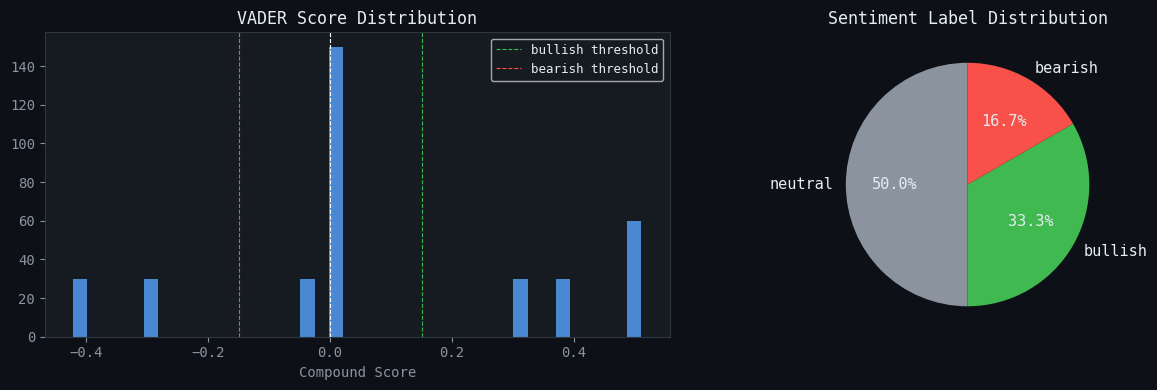

In [8]:
# ── Score distribution ──────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Histogram
axes[0].hist(df['sentiment_score'], bins=40, color='#58a6ff', alpha=0.8, edgecolor='none')
axes[0].axvline(0, color='white', lw=0.8, ls='--')
axes[0].axvline(0.15, color='#3fb950', lw=0.8, ls='--', label='bullish threshold')
axes[0].axvline(-0.15, color='#f85149', lw=0.8, ls='--', label='bearish threshold')
axes[0].set_title('VADER Score Distribution')
axes[0].set_xlabel('Compound Score')
axes[0].legend(fontsize=9)

# Label pie
counts = df['sentiment_label'].value_counts()
colors_pie = {'bullish': '#3fb950', 'bearish': '#f85149', 'neutral': '#8b949e'}
pie_colors = [colors_pie.get(l, 'grey') for l in counts.index]
axes[1].pie(counts.values, labels=counts.index, colors=pie_colors,
            autopct='%1.1f%%', startangle=90,
            textprops={'color': '#e6edf3', 'fontsize': 11})
axes[1].set_title('Sentiment Label Distribution')

plt.tight_layout()
plt.savefig('02_sentiment_distribution.png', dpi=120, bbox_inches='tight')
plt.show()

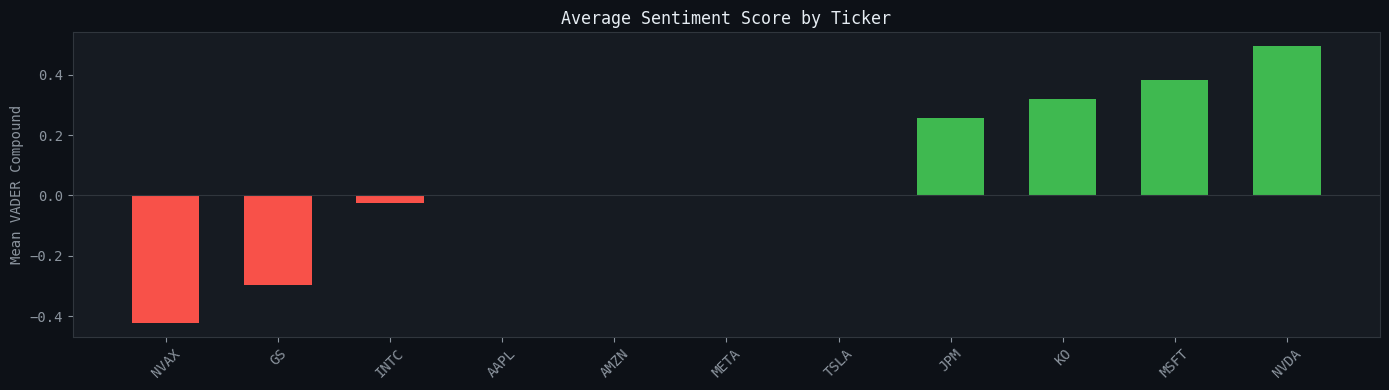

In [9]:
# ── Scores by ticker ────────────────────────────────────────────────────────
if df['ticker'].nunique() > 1:
    ticker_sentiment = df.groupby('ticker')['sentiment_score'].mean().sort_values()
    colors_bar = ['#f85149' if v < 0 else '#3fb950' for v in ticker_sentiment.values]

    fig, ax = plt.subplots(figsize=(14, 4))
    ax.bar(ticker_sentiment.index, ticker_sentiment.values, color=colors_bar, width=0.6)
    ax.axhline(0, color='#30363d', lw=0.8)
    ax.set_title('Average Sentiment Score by Ticker')
    ax.set_ylabel('Mean VADER Compound')
    ax.tick_params(axis='x', rotation=45)
    plt.tight_layout()
    plt.savefig('02_sentiment_by_ticker.png', dpi=120, bbox_inches='tight')
    plt.show()

In [10]:
# ── FinBERT fine-tuning (OPTIONAL — skip if no GPU) ────────────────────────
#
# This cell fine-tunes ProsusAI/finbert on your labelled headlines.
# Uncomment and run if you have a GPU or are willing to wait ~10min on CPU.
#
# FINBERT_FINETUNE = False  # Set True to run
#
# if FINBERT_FINETUNE:
#     from transformers import (AutoTokenizer, AutoModelForSequenceClassification,
#                               TrainingArguments, Trainer)
#     from datasets import Dataset
#     import torch
#
#     MODEL_ID   = 'ProsusAI/finbert'
#     OUTPUT_DIR = Path('../models/finbert_finetuned')
#     LABEL_MAP  = {'positive': 0, 'negative': 1, 'neutral': 2}
#
#     # Map VADER labels -> FinBERT label ids
#     label_map_rev = {'bullish': 0, 'bearish': 1, 'neutral': 2}
#     train_df = df[['headline','sentiment_label']].rename(
#         columns={'headline': 'text', 'sentiment_label': 'label'})
#     train_df['label'] = train_df['label'].map(label_map_rev)
#
#     tokenizer = AutoTokenizer.from_pretrained(MODEL_ID)
#     def tokenize(batch):
#         return tokenizer(batch['text'], truncation=True, padding='max_length', max_length=128)
#
#     ds = Dataset.from_pandas(train_df).map(tokenize, batched=True)
#     split = ds.train_test_split(test_size=0.1)
#
#     model = AutoModelForSequenceClassification.from_pretrained(MODEL_ID, num_labels=3)
#     args  = TrainingArguments(output_dir=str(OUTPUT_DIR), num_train_epochs=3,
#                               per_device_train_batch_size=16, evaluation_strategy='epoch',
#                               save_strategy='epoch', load_best_model_at_end=True,
#                               logging_steps=20, report_to='none')
#     trainer = Trainer(model=model, args=args,
#                       train_dataset=split['train'],
#                       eval_dataset=split['test'])
#     trainer.train()
#     trainer.save_model(str(OUTPUT_DIR))
#     tokenizer.save_pretrained(str(OUTPUT_DIR))
#     print(f'Model saved to {OUTPUT_DIR}')

print('FinBERT fine-tuning cell ready — set FINBERT_FINETUNE=True to run')

FinBERT fine-tuning cell ready — set FINBERT_FINETUNE=True to run


In [11]:
# ── Test sentiment_model.py live ───────────────────────────────────────────
from data.sentiment_model import score_text, label_sentiment

TEST_HEADLINES = [
    'NVIDIA smashes earnings, raises guidance on AI demand',
    'Tesla recalls 200,000 vehicles over battery fire risk',
    'Apple holds annual developer conference, no surprises',
    'Fed keeps rates unchanged, signals two cuts in 2025',
    'Biotech SAVA halts Alzheimer trial after adverse events',
    'Amazon AWS revenue grows 37% year-over-year',
]

print(f'{"-"*65}')
print(f'{"HEADLINE":<50} {"SCORE":>6}  {"LABEL"}')
print(f'{"-"*65}')
for h in TEST_HEADLINES:
    score = score_text(h)
    label = label_sentiment(score)
    color = '\033[32m' if label=='bullish' else '\033[31m' if label=='bearish' else '\033[33m'
    reset = '\033[0m'
    print(f'{h[:50]:<50} {score:>+6.3f}  {color}{label}{reset}')

-----------------------------------------------------------------
HEADLINE                                            SCORE  LABEL
-----------------------------------------------------------------
NVIDIA smashes earnings, raises guidance on AI dem -0.128  neutral
Tesla recalls 200,000 vehicles over battery fire r -0.542  bearish
Apple holds annual developer conference, no surpri -0.170  bearish
Fed keeps rates unchanged, signals two cuts in 202 -0.296  bearish
Biotech SAVA halts Alzheimer trial after adverse e -0.361  bearish
Amazon AWS revenue grows 37% year-over-year        +0.178  bullish
